## **Topic Modeling using LSA, LDA, and NMF**

Topic modeling is an unsupervised machine learning technique used to identify hidden themes or topics within a collection of documents. In this assignment, three popular topic modeling methods are applied:


*   Latent Semantic Analysis (LSA)

*   Latent Dirichlet Allocation (LDA)

*   Non-negative Matrix Factorization (NMF)


The goal is to compare these models based on their performance and interpretability.

In [23]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF, TruncatedSVD
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import normalize

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from wordcloud import WordCloud

In [25]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

### **Loading Dataset**

In [26]:
df = pd.read_csv("/content/drive/MyDrive/dataset/tripadvisor_hotel_reviews.csv")

In [27]:
df.head()

,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


In [28]:
df.isnull().sum()

,0
Review,0
Rating,0


In [29]:
df.shape

(20491, 2)

### **Text Preprocessing**

In [30]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [31]:
def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)

df['clean_text'] = df['Review'].apply(preprocess)

### **Vectorization**

In [21]:
tfidf = TfidfVectorizer(max_df=0.95, min_df=5)
tfidf_matrix = tfidf.fit_transform(df['clean_text'])

In [22]:
count = CountVectorizer(max_df=0.95, min_df=5)   # Count word for LDA
count_matrix = count.fit_transform(df['clean_text'])

### **Latent Semantic Analysis (LSA)**


In [36]:
# LSA
lsa = TruncatedSVD(n_components=7, random_state=42)
lsa_topics = lsa.fit_transform(tfidf_matrix)

### **Latent Dirichlet Allocation (LDA)**

In [37]:
# LDA
lda = LatentDirichletAllocation(n_components=7, random_state=42)
lda_topics = lda.fit_transform(count_matrix)

### **Non-negative Matrix Factorization (NMF)**

In [38]:
# NMF
nmf = NMF(n_components=7, random_state=42)
nmf_topics = nmf.fit_transform(tfidf_matrix)

### **Showing Top Word**

In [39]:
# Top words
def print_topics(model, feature_names, title):
    print(f"\n {title} Topics")
    for i, topic in enumerate(model.components_):
        words = [feature_names[j] for j in topic.argsort()[-10:]]
        print(f"Topic {i+1}: {', '.join(words)}")

print_topics(lsa, tfidf.get_feature_names_out(), "LSA")
print_topics(nmf, tfidf.get_feature_names_out(), "NMF")
print_topics(lda, count.get_feature_names_out(), "LDA")


 LSA Topics
Topic 1: night, nice, location, staff, stay, good, nt, great, room, hotel
Topic 2: water, day, time, vacation, nt, people, pool, food, beach, resort
Topic 3: food, wonderful, helpful, friendly, staff, beach, excellent, location, resort, great
Topic 4: beach, area, minute, clean, breakfast, value, station, nice, walk, good
Topic 5: airport, bus, euro, metro, barcelona, minute, star, station, excellent, hotel
Topic 6: bus, parking, car, walk, san, ca, street, great, place, nt
Topic 7: pool, parking, san, price, star, good, great, service, nice, hotel

 NMF Topics
Topic 1: lovely, wonderful, recommend, excellent, service, best, stay, stayed, staff, hotel
Topic 2: vacation, time, restaurant, beautiful, good, day, pool, food, beach, resort
Topic 3: loved, place, clean, room, helpful, friendly, stay, staff, location, great
Topic 4: excellent, value, hotel, clean, minute, location, breakfast, station, walk, good
Topic 5: day, service, small, desk, bathroom, view, night, floor, be

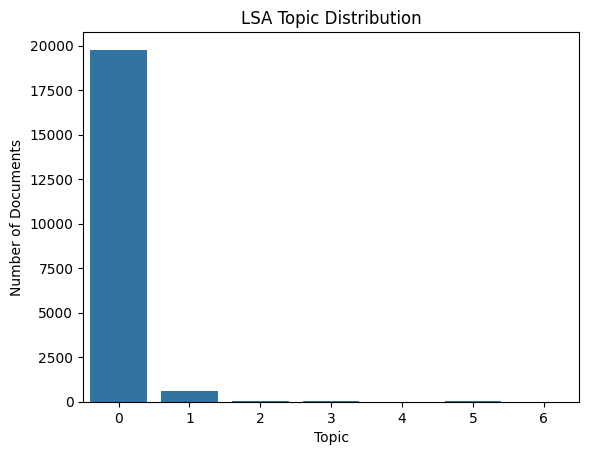

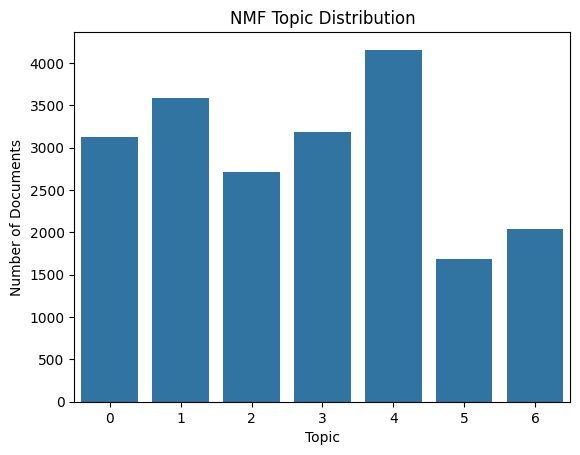

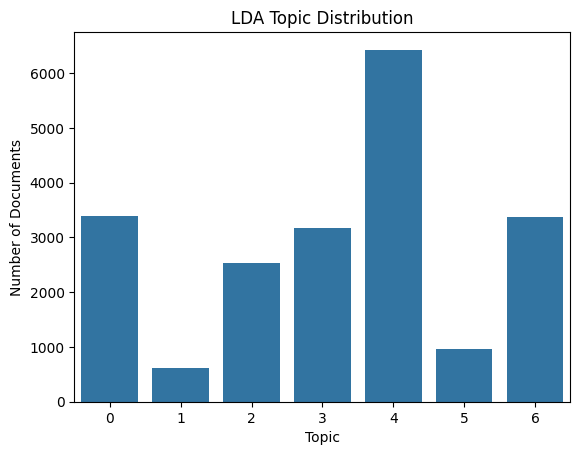

In [41]:
# Topic Distribution

def plot_topic_distribution(topic_matrix, title):
    topic_assignments = np.argmax(topic_matrix, axis=1)
    sns.countplot(x=topic_assignments)
    plt.title(title)
    plt.xlabel("Topic")
    plt.ylabel("Number of Documents")
    plt.show()

plot_topic_distribution(lsa_topics, "LSA Topic Distribution")
plot_topic_distribution(nmf_topics, "NMF Topic Distribution")
plot_topic_distribution(lda_topics, "LDA Topic Distribution")

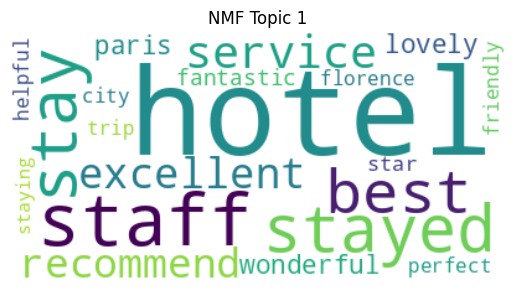

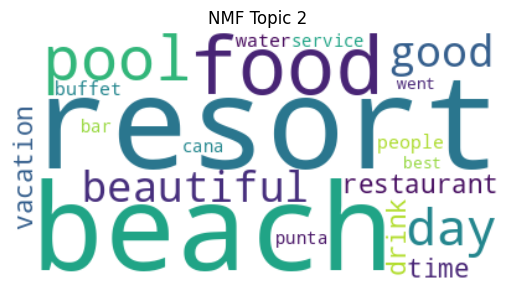

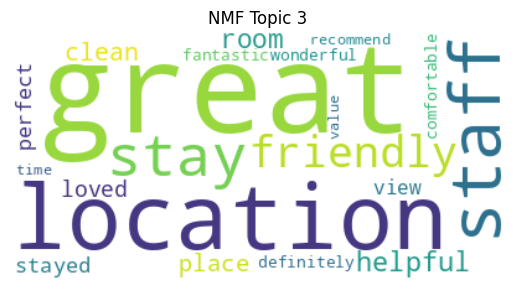

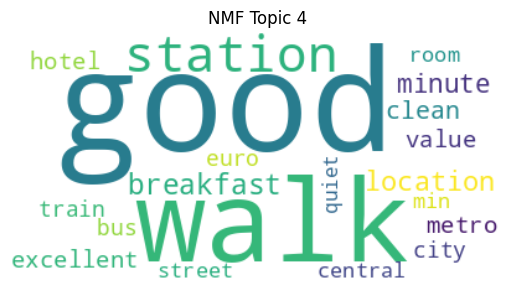

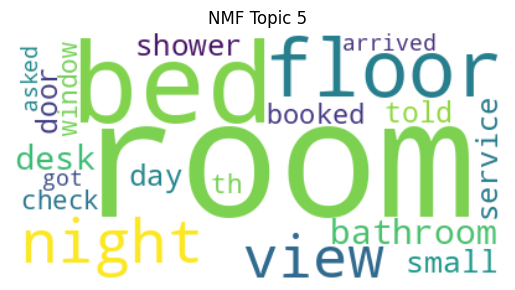

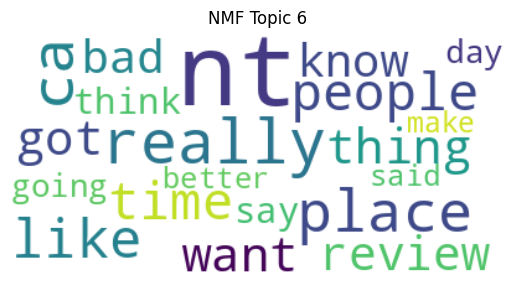

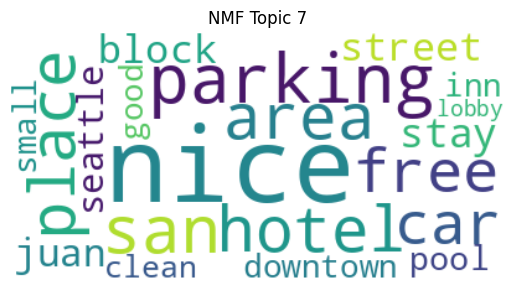

In [42]:
# Word Cloud (NMF)
feature_names = tfidf.get_feature_names_out()

for i, topic in enumerate(nmf.components_):
    word_freq = {feature_names[j]: topic[j] for j in topic.argsort()[-20:]}
    wc = WordCloud(background_color="white").generate_from_frequencies(word_freq)

    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"NMF Topic {i+1}")
    plt.show()